In [1]:
import regex as re
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt
import mpl_toolkits.axisartist.axislines as axislines

C:\Users\isen1\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#agg_results_df.to_csv('results/evaluated_results.csv', index=False)
agg_results_df = pd.read_csv('results/evaluated_results_multiseed.csv')

In [3]:
agg_results_df.sort_values('weighted_tvd100_avg')

,questionnaire_item_id,response_type,persona_format,sample,model_id,parsing_method,seed,simulated_responses,valid_responses,accuracy,...,weighted_tvd10_avg,weighted_tvd10_std,tvd50_avg,tvd50_std,weighted_tvd50_avg,weighted_tvd50_std,tvd100_avg,tvd100_std,weighted_tvd100_avg,weighted_tvd100_std
633,2,openResponse,firstPerson,0,Olmo-3.1-32B-Instruct,LLMjudge,45,4779,4779,0.680268,...,0.110146,0.076144,0.088166,0.054792,0.095154,0.067997,0.083346,0.055254,0.085072,0.064138
600,2,openResponse,firstPerson,0,Llama-3.1-8B-Instruct,LLMjudge,42,4779,4779,0.633605,...,0.119003,0.080048,0.085451,0.047370,0.097955,0.063432,0.079327,0.042461,0.086328,0.045348
631,2,openResponse,firstPerson,0,Olmo-3.1-32B-Instruct,LLMjudge,43,4779,4779,0.680686,...,0.116459,0.094726,0.086409,0.055547,0.091210,0.069153,0.080503,0.056933,0.086815,0.068552
632,2,openResponse,firstPerson,0,Olmo-3.1-32B-Instruct,LLMjudge,44,4779,4779,0.673572,...,0.119426,0.090449,0.087621,0.055649,0.097442,0.070714,0.083013,0.054760,0.088154,0.064074
75,1,jsonResponse,firstPerson,0,Olmo-3.1-32B-Instruct,jsonParsing,42,4779,4779,0.684871,...,0.116326,0.092869,0.079371,0.055473,0.096109,0.070733,0.074936,0.059329,0.090308,0.071274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,2,openResponse,demogrInterview,0,Olmo-3-7B-Instruct,regex,46,4779,4571,NaN,...,0.476144,0.142535,0.474976,0.150654,0.475456,0.141728,0.472156,0.162112,0.472138,0.150103
567,2,openResponse,demogrInterview,0,Olmo-3-7B-Instruct,regex,44,4779,4553,NaN,...,0.471835,0.150573,0.478021,0.155134,0.478444,0.152875,0.473780,0.165065,0.473097,0.157228
566,2,openResponse,demogrInterview,0,Olmo-3-7B-Instruct,regex,43,4779,4568,NaN,...,0.477603,0.150887,0.483765,0.154975,0.479003,0.147849,0.477580,0.163308,0.473988,0.153175
565,2,openResponse,demogrInterview,0,Olmo-3-7B-Instruct,regex,42,4779,4582,NaN,...,0.478932,0.145559,0.479866,0.153751,0.475574,0.147729,0.477182,0.165115,0.476431,0.153358


In [4]:
plot_df = agg_results_df.copy()
plot_df['Survey Question'] = plot_df.questionnaire_item_id.replace({1: 'Version 1', 2: 'Version 2'})
plot_df['response_type'] = plot_df.response_type.replace({'jsonResponse': 'JSON structured output', 'openResponse': 'open-ended response'})
plot_df['parsing_method'] = plot_df.parsing_method.replace({'jsonParsing': 'JSON parsing', 'regex': 'regex parsing', 'LLMjudge': 'LLM-as-a-judge'})
plot_df['Persona Information'] = plot_df.persona_format.apply(lambda x:'demographic only' if 'demogr' in x else 'demographics & attitudes')
plot_df['Persona Format'] = plot_df.persona_format.apply(lambda x:'first person' if 'Person' in x else 'interview')

plot_df = plot_df.drop(columns=['questionnaire_item_id', 'persona_format', 'sample'])
plot_df = plot_df.rename(columns={
    'response_type': 'Output Generation',
    'model_id': 'LLM model ID',
    'parsing_method': 'Output Parsing',
})
plot_df

,Output Generation,LLM model ID,Output Parsing,seed,simulated_responses,valid_responses,accuracy,weighted_accuracy,macro_avg_f1,weighted_f1,...,tvd50_std,weighted_tvd50_avg,weighted_tvd50_std,tvd100_avg,tvd100_std,weighted_tvd100_avg,weighted_tvd100_std,Survey Question,Persona Information,Persona Format
0,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,42,4779,4779,0.473739,0.482052,0.369138,0.443994,...,0.123082,0.249947,0.102428,0.285841,0.115613,0.256329,0.101207,Version 1,demographic only,first person
1,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,43,4779,4779,0.480226,0.487383,0.350443,0.430191,...,0.124687,0.298721,0.104813,0.339670,0.124758,0.306578,0.102671,Version 1,demographic only,first person
2,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,44,4779,4779,0.478552,0.485143,0.353808,0.430031,...,0.126018,0.298958,0.105440,0.338620,0.127120,0.304260,0.103445,Version 1,demographic only,first person
3,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,45,4779,4779,0.480226,0.485528,0.349917,0.429834,...,0.124145,0.293930,0.104263,0.339509,0.124337,0.300749,0.100156,Version 1,demographic only,first person
4,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,46,4779,4779,0.481272,0.491380,0.352592,0.436142,...,0.122546,0.294043,0.104805,0.339804,0.124384,0.302291,0.100501,Version 1,demographic only,first person
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,42,4779,4779,0.662063,0.633693,0.522161,0.589213,...,0.075581,0.195018,0.084009,0.183785,0.065994,0.190591,0.072004,Version 2,demographics & attitudes,interview
716,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,43,4779,4779,0.657460,0.630315,0.515899,0.584497,...,0.079437,0.209321,0.088124,0.196416,0.070474,0.205527,0.076597,Version 2,demographics & attitudes,interview
717,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,44,4779,4779,0.660180,0.630750,0.516177,0.585092,...,0.078250,0.208338,0.085941,0.193138,0.068522,0.202314,0.075235,Version 2,demographics & attitudes,interview
718,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,45,4779,4779,0.662272,0.634518,0.521115,0.588717,...,0.078456,0.205257,0.087040,0.193565,0.069739,0.200346,0.079350,Version 2,demographics & attitudes,interview


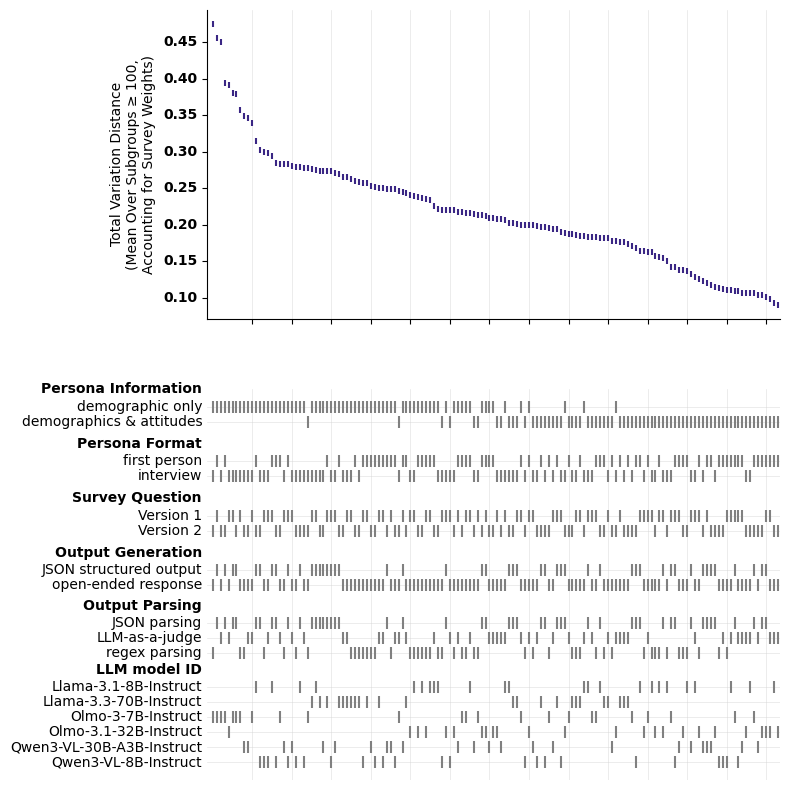

In [5]:
MEASURES = [
    #('Corr. of Quality Estimate with Ground-Truth', 'year_quality_fullData_pearson_r', 'year_quality_pearson', False), # display name, col in df, file name, lower is better
    #('Total Variation Distance\n(Mean Over Subgroups ≥ 100)', 'tvd100_avg', 'tvd100_avg', True),
    ('Total Variation Distance\n(Mean Over Subgroups ≥ 100,\nAccounting for Survey Weights)', 'weighted_tvd100_avg', 'weighted_tvd100_avg', True),
]
GROUP_COLS = ['Persona Information', 'Persona Format', 'Survey Question', 'Output Generation', 'Output Parsing', 'LLM model ID']

INVALID_THRESHOLD = 0.1 # do not plot results with more invalid responses

plot_df = plot_df.sort_values(by=GROUP_COLS)

for measure_title, measure_col, measure_short, lower_is_better in MEASURES[:]:

    # ---- Aggregate over specifications ----
    agg = plot_df
    #agg.loc[agg[measure_col] > 1, measure_col] = np.nan # exclude invalid values
    agg = plot_df.groupby(GROUP_COLS, observed=True)[measure_col].agg(["mean", "std"])
    #agg['invalid'] = plot_df.groupby(GROUP_COLS, observed=True)['total_invalid'].mean()
#
    ## Exclude invalid responses
    #invalid_agg = (agg.invalid > INVALID_THRESHOLD) #TODO: fix too large/inf values
    #if invalid_agg.any():
    #    print(f'Not plotting the following datapoints because of too many invalid responses:')
    #    display(agg[invalid_agg].sort_values('invalid'))
    #agg.loc[invalid_agg, ['mean', 'std']] = np.nan
    

    # ---- Sort by mean metric ----
    agg = agg.sort_values("mean", ascending=(not lower_is_better), na_position='first').reset_index()

    # ---- Colors for methods ----
    #method_colors = {m: c for m, c in zip(sorted(agg["answer_production_method"].unique()), plt.cm.tab10.colors)}
    #method_colors = {m:c for m, c in zip(method_names.values(), hue_colors)}
    method_colors = {}

    # ---- Plot ----
    #fig, (ax_curve, ax_specs) = plt.subplots(
    #    2, 1, figsize=(5, 6), gridspec_kw={'height_ratios': [2.5, 3]}, sharex=True
    #)

    fig = plt.figure(figsize=(8, 8)) #(6, 6)

    # Create your grid manually, like plt.subplots does internally
    gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 1.9])

    # First subplot
    ax_curve = fig.add_subplot(gs[0], axes_class=axislines.Axes)
    # Second subplot
    ax_specs = fig.add_subplot(gs[1], axes_class=axislines.Axes, sharex=ax_curve)


    # Top: specification curve
    for j in range(len(agg)):
        #method = agg.loc[j, 'Survey Response Generation Method']
        method = ''
        color = method_colors.get(method, "#3A2684")
        ax_curve.errorbar(
            x=j,
            y=agg.loc[j, "mean"],
            #yerr=agg.loc[j, "std"],
            #fmt="o",
            fmt='|',
            ecolor=color,
            elinewidth=1,
            capsize=0,
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=4, #3
            markeredgewidth=1.5
        )

    ax_curve.set_ylabel(measure_title)
    #ax_curve.legend(frameon=False)
    ax_curve.set_xlim([-0.5, len(agg)-0.5])

    # Bottom: indicator lines for each unique value of each variable
    # Reversed order: model_id on top, then answer_production_method, answer_scale_variant, temperature
    var_order = GROUP_COLS.copy()
    var_order.reverse()

    # Assign y-positions for each unique value within each variable
    y_positions = {}
    base_y = 1
    y_offset = 1.1
    ytick_labels = []
    major_ytick_labels = [] # headings
    ytick_positions = []
    major_ytick_positions = []
    separators = []
    for var in var_order:
        unique_vals = plot_df[var].unique()[::-1]
        for k, val in enumerate(unique_vals):
            y_positions[(var, str(val))] = base_y + k*y_offset
            ytick_labels.append(str(val))
            ytick_positions.append(base_y + k*y_offset)
            separators.append(base_y + k*y_offset)
        if var == 'Survey Response Generation Method':
            major_ytick_labels.append('Survey Response\nGeneration Method')
        else:
            major_ytick_labels.append(var)
        major_ytick_positions.append(base_y + (k + .7)*y_offset)
        base_y += len(unique_vals) + 2  # gap between groups
        if var == 'model': base_y += 1  # fix spacing

    # Plot markers and horizontal lines for each configuration
    for j in range(len(agg)):
        for var in var_order:
            val = str(agg.loc[j, var])
            y = y_positions[(var, val)]
            if np.isnan(agg.loc[j, 'mean']).any():
                color = "lightgray"
            elif var == 'Survey Response Generation Method':
                color = method_colors.get(val, "gray")
            else:
                color = "gray"
            # optionally, always color the bars according to the method -> overwhelming
            #else:
            #    _method = str(agg.loc[j, 'Survey Response Generation Method'])
            #    color = method_colors.get(_method, "gray")
            ax_specs.plot(j, y, marker="|", color=color, markersize=8, markeredgewidth=1.5)

    # Add horizontal lines for each configuration row
    for y in ytick_positions:
        ax_specs.axhline(y, color="lightgray", linestyle="-", linewidth=0.5, alpha=0.6, zorder=0)
    
    step = 10 #int(len(agg)/10)
    _vlines = list(range(step, len(agg), step))
    #_vlines = [i-0.25 for i in range(len(agg)-10,0,-10)]
    for x in _vlines:
        ax_specs.axvline(x, color='lightgray', ls='-', linewidth=0.5, alpha=0.6, zorder=0)
        ax_curve.axvline(x, color='lightgray', ls='-', linewidth=0.5, alpha=0.6, zorder=0)

    # Format y-axis
    ax_specs.set_yticks(ytick_positions, labels=ytick_labels, fontsize='small', minor=True)
    ax_specs.tick_params(axis='y', which='minor', labelsize='small')
    ax_specs.set_yticks(major_ytick_positions, labels=major_ytick_labels, fontsize=10)
    ax_specs.axis['left'].major_ticklabels.set(ha='right', va='bottom', fontsize=10, fontweight='bold', linespacing=1.1) #pad=-70,
    ax_specs.axis['left'].minor_ticklabels.set(fontsize=10)

    # Adjust x-axis and extra borders
    labels = ['' for i in _vlines] #[str(i) for i in range(10,len(agg),10)]
    ax_curve.set_xticks(_vlines, labels=labels)
    ax_curve.set_xlabel(None) #\nranked by {measure_title}
    ax_curve.axis['bottom'].major_ticklabels.set(fontsize=10)
    ax_curve.axis['bottom'].label.set(fontsize=10)
    ax_curve.axis['bottom'].major_ticks.set_tick_out(True)
    ax_curve.axis['left'].major_ticklabels.set(fontsize=10, fontweight='bold', color='black') #'#3A2684'
    ax_curve.axis['left'].label.set(fontsize=10)
    ax_curve.axis['left'].major_ticks.set_tick_out(True)
    ax_specs.axis['bottom'].major_ticklabels.set_visible(False)
    #ax_specs.axis['bottom'].major_ticks.set_tick_out(True)

    # Add an arrow to the left spine depending on which direction is better
    #ax_curve.axis['left'].set_axisline_style("-|>", size=1.5)

    for spine in ["top", "right"]:
        ax_specs.axis[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax_specs.axis[spine].line.set_visible(False) # remove spine
        ax_specs.axis[spine].major_ticks.set_ticksize(0) # remove ticks
        ax_specs.axis[spine].minor_ticks.set_ticksize(0) # remove ticks
    for spine in ["top", "right"]:
        ax_curve.axis[spine].set_visible(False)
    
    xmin, xmax = ax_curve.get_xlim()
    ax_curve.set_xlim(xmin-1, xmax) # add padding next to spine

    #ax_curve.set_ylim(0.82,1)

    ymin, ymax = ax_specs.get_ylim()
    #ax_specs.set_ylim(ymin, ymax + 0.8) # add padding for heading

    # Get the bounding box of the axes including ticklabels
    bbox = ax_curve.get_tightbbox(fig.canvas.get_renderer())
    # Center-align Figure title
    bbox = bbox.transformed(fig.transFigure.inverted()) # Convert bbox to figure coordinates
    x_center = 0.57 * (bbox.x0 + bbox.x1) # Compute center x in figure coordinates

    #fig.text(x_center, bbox.y1 + 0.11, "Annotator quality:\nMTME estimate ⟷ Gold-standard",
    #         ha='center', va='bottom', fontsize=10) #fontweight='bold'

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2)
    #plt.savefig(f'../plots/MTME_multiverse/specificationCurve_{measure_short}.pdf', bbox_inches='tight')
    plt.show()

In [6]:
agg_results_df

,questionnaire_item_id,response_type,persona_format,sample,model_id,parsing_method,seed,simulated_responses,valid_responses,accuracy,...,weighted_tvd10_avg,weighted_tvd10_std,tvd50_avg,tvd50_std,weighted_tvd50_avg,weighted_tvd50_std,tvd100_avg,tvd100_std,weighted_tvd100_avg,weighted_tvd100_std
0,1,jsonResponse,demogrFirstPerson,0,Llama-3.1-8B-Instruct,jsonParsing,42,4779,4779,0.473739,...,0.262496,0.119394,0.275851,0.123082,0.249947,0.102428,0.285841,0.115613,0.256329,0.101207
1,1,jsonResponse,demogrFirstPerson,0,Llama-3.1-8B-Instruct,jsonParsing,43,4779,4779,0.480226,...,0.310281,0.122338,0.333972,0.124687,0.298721,0.104813,0.339670,0.124758,0.306578,0.102671
2,1,jsonResponse,demogrFirstPerson,0,Llama-3.1-8B-Instruct,jsonParsing,44,4779,4779,0.478552,...,0.308741,0.124360,0.332549,0.126018,0.298958,0.105440,0.338620,0.127120,0.304260,0.103445
3,1,jsonResponse,demogrFirstPerson,0,Llama-3.1-8B-Instruct,jsonParsing,45,4779,4779,0.480226,...,0.302013,0.117560,0.333228,0.124145,0.293930,0.104263,0.339509,0.124337,0.300749,0.100156
4,1,jsonResponse,demogrFirstPerson,0,Llama-3.1-8B-Instruct,jsonParsing,46,4779,4779,0.481272,...,0.299533,0.122636,0.333096,0.122546,0.294043,0.104805,0.339804,0.124384,0.302291,0.100501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,2,openResponse,interview,0,Qwen3-VL-8B-Instruct,regex,42,4779,4779,0.662063,...,0.211304,0.110580,0.188046,0.075581,0.195018,0.084009,0.183785,0.065994,0.190591,0.072004
716,2,openResponse,interview,0,Qwen3-VL-8B-Instruct,regex,43,4779,4779,0.657460,...,0.223751,0.109404,0.201256,0.079437,0.209321,0.088124,0.196416,0.070474,0.205527,0.076597
717,2,openResponse,interview,0,Qwen3-VL-8B-Instruct,regex,44,4779,4779,0.660180,...,0.226955,0.110405,0.198909,0.078250,0.208338,0.085941,0.193138,0.068522,0.202314,0.075235
718,2,openResponse,interview,0,Qwen3-VL-8B-Instruct,regex,45,4779,4779,0.662272,...,0.223724,0.108496,0.199413,0.078456,0.205257,0.087040,0.193565,0.069739,0.200346,0.079350


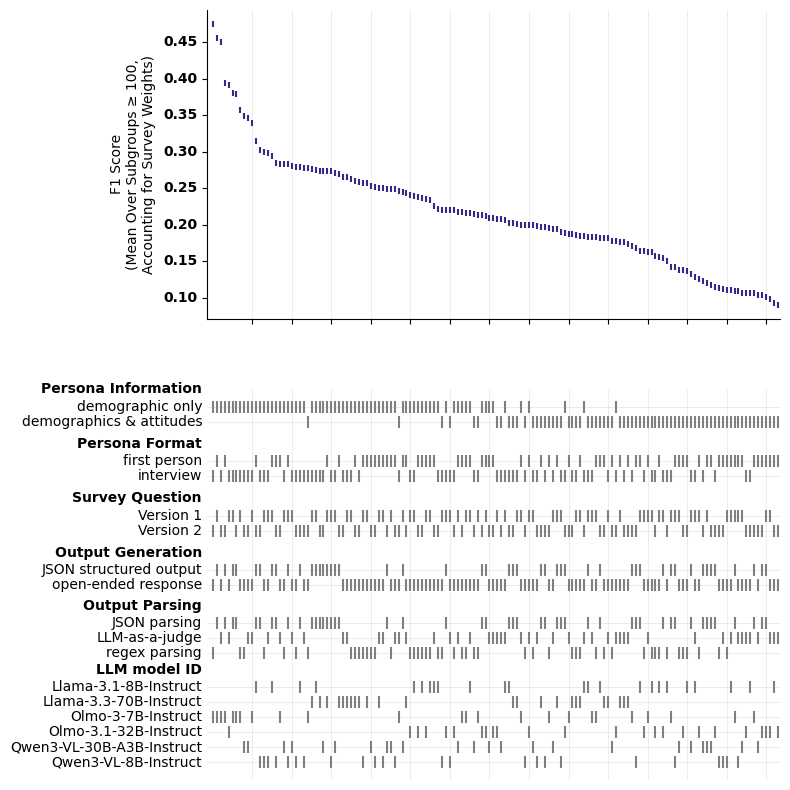

In [7]:
MEASURES = [
    #('Corr. of Quality Estimate with Ground-Truth', 'year_quality_fullData_pearson_r', 'year_quality_pearson', False), # display name, col in df, file name, lower is better
    #('Total Variation Distance\n(Mean Over Subgroups ≥ 100)', 'tvd100_avg', 'tvd100_avg', True),
    #('Total Variation Distance\n(Mean Over Subgroups ≥ 100,\nAccounting for Survey Weights)', 'weighted_tvd100_avg', 'weighted_tvd100_avg', True),
    ('F1 Score\n(Mean Over Subgroups ≥ 100,\nAccounting for Survey Weights)', 'weighted_tvd100_avg', 'weighted_tvd100_avg', True)
]
GROUP_COLS = ['Persona Information', 'Persona Format', 'Survey Question', 'Output Generation', 'Output Parsing', 'LLM model ID']

INVALID_THRESHOLD = 0.1 # do not plot results with more invalid responses

plot_df = plot_df.sort_values(by=GROUP_COLS)

for measure_title, measure_col, measure_short, lower_is_better in MEASURES[:]:

    # ---- Aggregate over specifications ----
    agg = plot_df
    #agg.loc[agg[measure_col] > 1, measure_col] = np.nan # exclude invalid values
    agg = plot_df.groupby(GROUP_COLS, observed=True)[measure_col].agg(["mean", "std"])
    #agg['invalid'] = plot_df.groupby(GROUP_COLS, observed=True)['total_invalid'].mean()
#
    ## Exclude invalid responses
    #invalid_agg = (agg.invalid > INVALID_THRESHOLD) #TODO: fix too large/inf values
    #if invalid_agg.any():
    #    print(f'Not plotting the following datapoints because of too many invalid responses:')
    #    display(agg[invalid_agg].sort_values('invalid'))
    #agg.loc[invalid_agg, ['mean', 'std']] = np.nan
    

    # ---- Sort by mean metric ----
    agg = agg.sort_values("mean", ascending=(not lower_is_better), na_position='first').reset_index()

    # ---- Colors for methods ----
    #method_colors = {m: c for m, c in zip(sorted(agg["answer_production_method"].unique()), plt.cm.tab10.colors)}
    #method_colors = {m:c for m, c in zip(method_names.values(), hue_colors)}
    method_colors = {}

    # ---- Plot ----
    #fig, (ax_curve, ax_specs) = plt.subplots(
    #    2, 1, figsize=(5, 6), gridspec_kw={'height_ratios': [2.5, 3]}, sharex=True
    #)

    fig = plt.figure(figsize=(8, 8)) #(6, 6)

    # Create your grid manually, like plt.subplots does internally
    gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 1.9])

    # First subplot
    ax_curve = fig.add_subplot(gs[0], axes_class=axislines.Axes)
    # Second subplot
    ax_specs = fig.add_subplot(gs[1], axes_class=axislines.Axes, sharex=ax_curve)


    # Top: specification curve
    for j in range(len(agg)):
        #method = agg.loc[j, 'Survey Response Generation Method']
        method = ''
        color = method_colors.get(method, "#3A2684")
        ax_curve.errorbar(
            x=j,
            y=agg.loc[j, "mean"],
            #yerr=agg.loc[j, "std"],
            #fmt="o",
            fmt='|',
            ecolor=color,
            elinewidth=1,
            capsize=0,
            markerfacecolor=color,
            markeredgecolor=color,
            markersize=4, #3
            markeredgewidth=1.5
        )

    ax_curve.set_ylabel(measure_title)
    #ax_curve.legend(frameon=False)
    ax_curve.set_xlim([-0.5, len(agg)-0.5])

    # Bottom: indicator lines for each unique value of each variable
    # Reversed order: model_id on top, then answer_production_method, answer_scale_variant, temperature
    var_order = GROUP_COLS.copy()
    var_order.reverse()

    # Assign y-positions for each unique value within each variable
    y_positions = {}
    base_y = 1
    y_offset = 1.1
    ytick_labels = []
    major_ytick_labels = [] # headings
    ytick_positions = []
    major_ytick_positions = []
    separators = []
    for var in var_order:
        unique_vals = plot_df[var].unique()[::-1]
        for k, val in enumerate(unique_vals):
            y_positions[(var, str(val))] = base_y + k*y_offset
            ytick_labels.append(str(val))
            ytick_positions.append(base_y + k*y_offset)
            separators.append(base_y + k*y_offset)
        if var == 'Survey Response Generation Method':
            major_ytick_labels.append('Survey Response\nGeneration Method')
        else:
            major_ytick_labels.append(var)
        major_ytick_positions.append(base_y + (k + .7)*y_offset)
        base_y += len(unique_vals) + 2  # gap between groups
        if var == 'model': base_y += 1  # fix spacing

    # Plot markers and horizontal lines for each configuration
    for j in range(len(agg)):
        for var in var_order:
            val = str(agg.loc[j, var])
            y = y_positions[(var, val)]
            if np.isnan(agg.loc[j, 'mean']).any():
                color = "lightgray"
            elif var == 'Survey Response Generation Method':
                color = method_colors.get(val, "gray")
            else:
                color = "gray"
            # optionally, always color the bars according to the method -> overwhelming
            #else:
            #    _method = str(agg.loc[j, 'Survey Response Generation Method'])
            #    color = method_colors.get(_method, "gray")
            ax_specs.plot(j, y, marker="|", color=color, markersize=8, markeredgewidth=1.5)

    # Add horizontal lines for each configuration row
    for y in ytick_positions:
        ax_specs.axhline(y, color="lightgray", linestyle="-", linewidth=0.5, alpha=0.6, zorder=0)
    
    step = 10 #int(len(agg)/10)
    _vlines = list(range(step, len(agg), step))
    #_vlines = [i-0.25 for i in range(len(agg)-10,0,-10)]
    for x in _vlines:
        ax_specs.axvline(x, color='lightgray', ls='-', linewidth=0.5, alpha=0.6, zorder=0)
        ax_curve.axvline(x, color='lightgray', ls='-', linewidth=0.5, alpha=0.6, zorder=0)

    # Format y-axis
    ax_specs.set_yticks(ytick_positions, labels=ytick_labels, fontsize='small', minor=True)
    ax_specs.tick_params(axis='y', which='minor', labelsize='small')
    ax_specs.set_yticks(major_ytick_positions, labels=major_ytick_labels, fontsize=10)
    ax_specs.axis['left'].major_ticklabels.set(ha='right', va='bottom', fontsize=10, fontweight='bold', linespacing=1.1) #pad=-70,
    ax_specs.axis['left'].minor_ticklabels.set(fontsize=10)

    # Adjust x-axis and extra borders
    labels = ['' for i in _vlines] #[str(i) for i in range(10,len(agg),10)]
    ax_curve.set_xticks(_vlines, labels=labels)
    ax_curve.set_xlabel(None) #\nranked by {measure_title}
    ax_curve.axis['bottom'].major_ticklabels.set(fontsize=10)
    ax_curve.axis['bottom'].label.set(fontsize=10)
    ax_curve.axis['bottom'].major_ticks.set_tick_out(True)
    ax_curve.axis['left'].major_ticklabels.set(fontsize=10, fontweight='bold', color='black') #'#3A2684'
    ax_curve.axis['left'].label.set(fontsize=10)
    ax_curve.axis['left'].major_ticks.set_tick_out(True)
    ax_specs.axis['bottom'].major_ticklabels.set_visible(False)
    #ax_specs.axis['bottom'].major_ticks.set_tick_out(True)

    # Add an arrow to the left spine depending on which direction is better
    #ax_curve.axis['left'].set_axisline_style("-|>", size=1.5)

    for spine in ["top", "right"]:
        ax_specs.axis[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax_specs.axis[spine].line.set_visible(False) # remove spine
        ax_specs.axis[spine].major_ticks.set_ticksize(0) # remove ticks
        ax_specs.axis[spine].minor_ticks.set_ticksize(0) # remove ticks
    for spine in ["top", "right"]:
        ax_curve.axis[spine].set_visible(False)
    
    xmin, xmax = ax_curve.get_xlim()
    ax_curve.set_xlim(xmin-1, xmax) # add padding next to spine

    #ax_curve.set_ylim(0.82,1)

    ymin, ymax = ax_specs.get_ylim()
    #ax_specs.set_ylim(ymin, ymax + 0.8) # add padding for heading

    # Get the bounding box of the axes including ticklabels
    bbox = ax_curve.get_tightbbox(fig.canvas.get_renderer())
    # Center-align Figure title
    bbox = bbox.transformed(fig.transFigure.inverted()) # Convert bbox to figure coordinates
    x_center = 0.57 * (bbox.x0 + bbox.x1) # Compute center x in figure coordinates

    #fig.text(x_center, bbox.y1 + 0.11, "Annotator quality:\nMTME estimate ⟷ Gold-standard",
    #         ha='center', va='bottom', fontsize=10) #fontweight='bold'

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2)
    #plt.savefig(f'../plots/MTME_multiverse/specificationCurve_{measure_short}.pdf', bbox_inches='tight')
    plt.show()

In [8]:
plot_df.columns

Index(['Output Generation', 'LLM model ID', 'Output Parsing', 'seed',
       'simulated_responses', 'valid_responses', 'accuracy',
       'weighted_accuracy', 'macro_avg_f1', 'weighted_f1', 'f1_Trump',
       'f1_Harris', 'f1_Non-voter', 'tvd_avg', 'tvd_std', 'weighted_tvd_avg',
       'weighted_tvd_std', 'tvd10_avg', 'tvd10_std', 'weighted_tvd10_avg',
       'weighted_tvd10_std', 'tvd50_avg', 'tvd50_std', 'weighted_tvd50_avg',
       'weighted_tvd50_std', 'tvd100_avg', 'tvd100_std', 'weighted_tvd100_avg',
       'weighted_tvd100_std', 'Survey Question', 'Persona Information',
       'Persona Format'],
      dtype='object')

In [ ]:
metric = 'tvd_avg' # weighted_f1

In [9]:
dep_vars = ['weighted_f1', 'f1_Trump',
       'f1_Harris', 'f1_Non_voter'
       ]
indep_vars = ['Output Generation', 'LLM model ID', 'Output Parsing', 'Survey Question', 'Persona Information',
       'Persona Format']

In [10]:
from statsmodels.formula.api import ols, logit
from stargazer.stargazer import Stargazer

In [11]:
plot_df = plot_df.rename(columns={i : '_'.join(i.split()) for i in indep_vars})
indep_vars = ['_'.join(i.split()) for i in indep_vars]
plot_df[indep_vars]

,Output_Generation,LLM_model_ID,Output_Parsing,Survey_Question,Persona_Information,Persona_Format
0,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,Version 1,demographic only,first person
1,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,Version 1,demographic only,first person
2,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,Version 1,demographic only,first person
3,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,Version 1,demographic only,first person
4,JSON structured output,Llama-3.1-8B-Instruct,JSON parsing,Version 1,demographic only,first person
...,...,...,...,...,...,...
715,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,Version 2,demographics & attitudes,interview
716,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,Version 2,demographics & attitudes,interview
717,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,Version 2,demographics & attitudes,interview
718,open-ended response,Qwen3-VL-8B-Instruct,regex parsing,Version 2,demographics & attitudes,interview


In [12]:
for var in indep_vars:
    print(var)
    print(plot_df[var].unique())

Output_Generation
['JSON structured output' 'open-ended response']
LLM_model_ID
['Llama-3.1-8B-Instruct' 'Llama-3.3-70B-Instruct' 'Olmo-3-7B-Instruct'
 'Olmo-3.1-32B-Instruct' 'Qwen3-VL-30B-A3B-Instruct'
 'Qwen3-VL-8B-Instruct']
Output_Parsing
['JSON parsing' 'LLM-as-a-judge' 'regex parsing']
Survey_Question
['Version 1' 'Version 2']
Persona_Information
['demographic only' 'demographics & attitudes']
Persona_Format
['first person' 'interview']


In [13]:
og_dict = {'JSON structured output': 'JSON',
           'open-ended response' : 'free-text'}
model_dict = {'Llama-3.1-8B-Instruct': 'Llama-8B',
              'Llama-3.3-70B-Instruct': 'Llama-70B',
              'Olmo-3-7B-Instruct': 'Olmo-7B',
              'Olmo-3.1-32B-Instruct': 'Olmo-32B',
              'Qwen3-VL-30B-A3B-Instruct': 'Qwen-30B',
              'Qwen3-VL-8B-Instruct': 'Qwen-8B'
             }
op_dict = {'JSON parsing': 'JSON_parsing',
           'LLM-as-a-judge': 'LLM judge',
           'regex parsing': 'regex'}

sq_dict = {'Version 1' : 'v1',
           'Version 2' : 'v2'}

pi_dict = {'demographic only': 'demo',
      'demographics & attitudes' : 'demo+att'}

pf_dict = {'first person' : 'first-person',
           'interview' : 'interview'}

In [14]:
### rename everything

og = []
models = []
op = []
sq = []
pi = []
pf = []

for _, row in plot_df.iterrows():
    og.append(og_dict[row['Output_Generation']])
    models.append(model_dict[row['LLM_model_ID']])
    op.append(op_dict[row['Output_Parsing']])
    sq.append(sq_dict[row['Survey_Question']])
    pi.append(pi_dict[row['Persona_Information']])
    pf.append(pf_dict[row['Persona_Format']])
    
plot_df['Output_Generation'] = og
plot_df['LLM_model_ID'] = models
plot_df['Output_Parsing'] = op
plot_df['Survey_Question'] = sq
plot_df['Persona_Information'] = pi
plot_df['Persona_Format'] = pf

In [15]:
### combine persona_format and persona_info into persona construction

plot_df['Persona'] = plot_df['Persona_Information'] + ' & ' + plot_df['Persona_Format']
plot_df

,Output_Generation,LLM_model_ID,Output_Parsing,seed,simulated_responses,valid_responses,accuracy,weighted_accuracy,macro_avg_f1,weighted_f1,...,weighted_tvd50_avg,weighted_tvd50_std,tvd100_avg,tvd100_std,weighted_tvd100_avg,weighted_tvd100_std,Survey_Question,Persona_Information,Persona_Format,Persona
0,JSON,Llama-8B,JSON_parsing,42,4779,4779,0.473739,0.482052,0.369138,0.443994,...,0.249947,0.102428,0.285841,0.115613,0.256329,0.101207,v1,demo,first-person,demo & first-person
1,JSON,Llama-8B,JSON_parsing,43,4779,4779,0.480226,0.487383,0.350443,0.430191,...,0.298721,0.104813,0.339670,0.124758,0.306578,0.102671,v1,demo,first-person,demo & first-person
2,JSON,Llama-8B,JSON_parsing,44,4779,4779,0.478552,0.485143,0.353808,0.430031,...,0.298958,0.105440,0.338620,0.127120,0.304260,0.103445,v1,demo,first-person,demo & first-person
3,JSON,Llama-8B,JSON_parsing,45,4779,4779,0.480226,0.485528,0.349917,0.429834,...,0.293930,0.104263,0.339509,0.124337,0.300749,0.100156,v1,demo,first-person,demo & first-person
4,JSON,Llama-8B,JSON_parsing,46,4779,4779,0.481272,0.491380,0.352592,0.436142,...,0.294043,0.104805,0.339804,0.124384,0.302291,0.100501,v1,demo,first-person,demo & first-person
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,free-text,Qwen-8B,regex,42,4779,4779,0.662063,0.633693,0.522161,0.589213,...,0.195018,0.084009,0.183785,0.065994,0.190591,0.072004,v2,demo+att,interview,demo+att & interview
716,free-text,Qwen-8B,regex,43,4779,4779,0.657460,0.630315,0.515899,0.584497,...,0.209321,0.088124,0.196416,0.070474,0.205527,0.076597,v2,demo+att,interview,demo+att & interview
717,free-text,Qwen-8B,regex,44,4779,4779,0.660180,0.630750,0.516177,0.585092,...,0.208338,0.085941,0.193138,0.068522,0.202314,0.075235,v2,demo+att,interview,demo+att & interview
718,free-text,Qwen-8B,regex,45,4779,4779,0.662272,0.634518,0.521115,0.588717,...,0.205257,0.087040,0.193565,0.069739,0.200346,0.079350,v2,demo+att,interview,demo+att & interview


In [16]:
indep_vars = ['Inference',
'LLM',
    'Behavior_Proc',
    'Task',
    'Persona'
    ]

In [17]:
plot_df = plot_df.rename(columns = {'Output_Generation': 'Inference',
                                    'LLM_model_ID': 'LLM',
                                    'Output_Parsing': 'Behavior_Proc',
                                    'Survey_Question': 'Task',
                                    })

In [18]:
plot_df = plot_df.rename(columns = {'f1_Non-voter' : 'f1_Non_voter'})
plot_df

,Inference,LLM,Behavior_Proc,seed,simulated_responses,valid_responses,accuracy,weighted_accuracy,macro_avg_f1,weighted_f1,...,weighted_tvd50_avg,weighted_tvd50_std,tvd100_avg,tvd100_std,weighted_tvd100_avg,weighted_tvd100_std,Task,Persona_Information,Persona_Format,Persona
0,JSON,Llama-8B,JSON_parsing,42,4779,4779,0.473739,0.482052,0.369138,0.443994,...,0.249947,0.102428,0.285841,0.115613,0.256329,0.101207,v1,demo,first-person,demo & first-person
1,JSON,Llama-8B,JSON_parsing,43,4779,4779,0.480226,0.487383,0.350443,0.430191,...,0.298721,0.104813,0.339670,0.124758,0.306578,0.102671,v1,demo,first-person,demo & first-person
2,JSON,Llama-8B,JSON_parsing,44,4779,4779,0.478552,0.485143,0.353808,0.430031,...,0.298958,0.105440,0.338620,0.127120,0.304260,0.103445,v1,demo,first-person,demo & first-person
3,JSON,Llama-8B,JSON_parsing,45,4779,4779,0.480226,0.485528,0.349917,0.429834,...,0.293930,0.104263,0.339509,0.124337,0.300749,0.100156,v1,demo,first-person,demo & first-person
4,JSON,Llama-8B,JSON_parsing,46,4779,4779,0.481272,0.491380,0.352592,0.436142,...,0.294043,0.104805,0.339804,0.124384,0.302291,0.100501,v1,demo,first-person,demo & first-person
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,free-text,Qwen-8B,regex,42,4779,4779,0.662063,0.633693,0.522161,0.589213,...,0.195018,0.084009,0.183785,0.065994,0.190591,0.072004,v2,demo+att,interview,demo+att & interview
716,free-text,Qwen-8B,regex,43,4779,4779,0.657460,0.630315,0.515899,0.584497,...,0.209321,0.088124,0.196416,0.070474,0.205527,0.076597,v2,demo+att,interview,demo+att & interview
717,free-text,Qwen-8B,regex,44,4779,4779,0.660180,0.630750,0.516177,0.585092,...,0.208338,0.085941,0.193138,0.068522,0.202314,0.075235,v2,demo+att,interview,demo+att & interview
718,free-text,Qwen-8B,regex,45,4779,4779,0.662272,0.634518,0.521115,0.588717,...,0.205257,0.087040,0.193565,0.069739,0.200346,0.079350,v2,demo+att,interview,demo+att & interview


In [19]:
dep_vars

['weighted_f1', 'f1_Trump', 'f1_Harris', 'f1_Non_voter']

In [20]:
for var in indep_vars:
    print(var, plot_df[var].unique())

Inference ['JSON' 'free-text']
LLM ['Llama-8B' 'Llama-70B' 'Olmo-7B' 'Olmo-32B' 'Qwen-30B' 'Qwen-8B']
Behavior_Proc ['JSON_parsing' 'LLM judge' 'regex']
Task ['v1' 'v2']
Persona ['demo & first-person' 'demo & interview' 'demo+att & first-person'
 'demo+att & interview']


In [52]:
mean = {}
std = {}
for var in indep_vars:
    mean[var] = dict(plot_df.groupby(var).mean(numeric_only = True)['tvd_avg'])
    std[var] = dict(plot_df.groupby(var).std(numeric_only = True)['tvd_avg'])

mean

{'Inference': {'JSON': 0.24399854709699997, 'free-text': 0.2225267604788878},
 'LLM': {'Llama-70B': 0.23145578059812444,
  'Llama-8B': 0.21543960325141248,
  'Olmo-32B': 0.1993107482177969,
  'Olmo-7B': 0.2832521713798144,
  'Qwen-30B': 0.2133923906380613,
  'Qwen-8B': 0.23525344202434162},
 'Behavior_Proc': {'JSON_parsing': 0.24399854709699997,
  'LLM judge': 0.22247640854746129,
  'regex': 0.2225771124103143},
 'Task': {'v1': 0.22846303171942972, 'v2': 0.23090501365042068},
 'Persona': {'demo & first-person': 0.27727387868836045,
  'demo & interview': 0.30886147434701744,
  'demo+att & first-person': 0.1401602465678818,
  'demo+att & interview': 0.19244049113644107}}

In [53]:
plot_df.mean(numeric_only = True)['tvd_avg'], plot_df.std(numeric_only = True)['tvd_avg']

(0.22968402268492522, 0.08408851664024812)

In [54]:
df_rows = []
for var in mean:
    for var2 in mean[var]:
        num = str(mean[var][var2].round(3)) + ' \u00B1 ' + str(std[var][var2].round(3))
        df_rows.append([var, var2, num])
    
num = str(plot_df.mean(numeric_only = True)['tvd_avg'].round(3)) + ' \u00B1 ' \
          + str(plot_df.std(numeric_only = True)['tvd_avg'].round(3))
df_rows.append(['Overall', 'Overall', num])
table = pd.DataFrame(df_rows)
table.columns = ['Design Choice', 'Variant', 'F1 (mean \u00B1 std)']
table

,Design Choice,Variant,F1 (mean ± std)
0,Inference,JSON,0.244 ± 0.092
1,Inference,free-text,0.223 ± 0.079
2,LLM,Llama-70B,0.231 ± 0.055
3,LLM,Llama-8B,0.215 ± 0.074
4,LLM,Olmo-32B,0.199 ± 0.074
5,LLM,Olmo-7B,0.283 ± 0.115
6,LLM,Qwen-30B,0.213 ± 0.072
7,LLM,Qwen-8B,0.235 ± 0.078
8,Behavior_Proc,JSON_parsing,0.244 ± 0.092
9,Behavior_Proc,LLM judge,0.222 ± 0.084


In [47]:
print(table.to_latex())

\begin{tabular}{llll}
\toprule
 & Design Choice & Variant & F1 (mean ± std) \\
\midrule
0 & Inference & JSON & 0.518 ± 0.096 \\
1 & Inference & free-text & 0.502 ± 0.09 \\
2 & LLM & Llama-70B & 0.514 ± 0.075 \\
3 & LLM & Llama-8B & 0.504 ± 0.073 \\
4 & LLM & Olmo-32B & 0.518 ± 0.102 \\
5 & LLM & Olmo-7B & 0.464 ± 0.103 \\
6 & LLM & Qwen-30B & 0.524 ± 0.09 \\
7 & LLM & Qwen-8B & 0.52 ± 0.094 \\
8 & Behavior_Proc & JSON_parsing & 0.518 ± 0.096 \\
9 & Behavior_Proc & LLM judge & 0.518 ± 0.094 \\
10 & Behavior_Proc & regex & 0.486 ± 0.083 \\
11 & Task & v1 & 0.508 ± 0.093 \\
12 & Task & v2 & 0.506 ± 0.092 \\
13 & Persona & demo & first-person & 0.429 ± 0.031 \\
14 & Persona & demo & interview & 0.417 ± 0.037 \\
15 & Persona & demo+att & first-person & 0.606 ± 0.039 \\
16 & Persona & demo+att & interview & 0.577 ± 0.036 \\
17 & Overall & Overall & 0.507 ± 0.092 \\
\bottomrule
\end{tabular}



In [23]:
indep_vars

['Inference', 'LLM', 'Behavior_Proc', 'Task', 'Persona']

In [24]:
# get the reference categories: the one that acheives the highest overall score
refs = {'Inference' : 'JSON',
        'LLM' : 'Qwen-30B',
        'Behavior_Proc' : 'JSON_parsing',
        'Task' : 'v1',
        'Persona' : 'demo+att & first-person'
       }

In [25]:
formula = ''
for var in indep_vars:
    formula = formula + 'C(' + var + ', Treatment(reference=\'' + refs[var] + '\'))+'
    
formula = formula[:-1]

In [26]:
formula

"C(Inference, Treatment(reference='JSON'))+C(LLM, Treatment(reference='Qwen-30B'))+C(Behavior_Proc, Treatment(reference='JSON_parsing'))+C(Task, Treatment(reference='v1'))+C(Persona, Treatment(reference='demo+att & first-person'))"

In [27]:
# ask georg about JSON parsing
# plot_df = plot_df[plot_df['Behavior_Proc'] != 'JSON_parsing']

In [28]:
regs = []
for dep_var in dep_vars:
    regs.append(ols(f"{dep_var} ~ {formula}",
          data = plot_df).fit(cov_type = 'HC3'))

stargazer = Stargazer(regs)
stargazer.significance_levels([0.05, 0.01, 0.001])
stargazer.show_model_numbers(False)
stargazer

C:\Users\isen1\anaconda3\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '
C:\Users\isen1\anaconda3\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '
C:\Users\isen1\anaconda3\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '
C:\Users\isen1\anaconda3\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

model_labels = ['Weighted F1', 'F1 Trump', 'F1 Harris', 'F1 Non-voter']
colors = ['#2166ac', '#d6604d', '#4dac26', '#b35806']

# Extract coefficients + 95% CIs from each fitted model
all_coefs = []
for reg, label in zip(regs, model_labels):
    ci = reg.conf_int()
    df_c = pd.DataFrame({
        'coef': reg.params,
        'ci_low': ci[0],
        'ci_high': ci[1],
        'pvalue': reg.pvalues,
        'model': label
    })
    df_c = df_c[df_c.index != 'Intercept']
    all_coefs.append(df_c)

coef_df = pd.concat(all_coefs).reset_index().rename(columns={'index': 'variable'})

def clean_name(v):
    m = re.search(r'\[T\.(.*)\]', v)
    val = m.group(1) if m else v
    grp_m = re.search(r'C\((\w+)\)', v)
    grp = grp_m.group(1).replace('_', ' ') if grp_m else ''
    return f'{grp}: {val}' if grp else val

coef_df['label'] = coef_df['variable'].apply(clean_name)

In [30]:
coef_df

,variable,coef,ci_low,ci_high,pvalue,model,label
0,"C(Inference, Treatment(reference='JSON'))[T.fr...",-0.010961,-0.013581,-0.008342,2.360450e-16,Weighted F1,free-text
1,"C(LLM, Treatment(reference='Qwen-30B'))[T.Llam...",-0.010596,-0.015120,-0.006072,4.414435e-06,Weighted F1,Llama-70B
2,"C(LLM, Treatment(reference='Qwen-30B'))[T.Llam...",-0.020131,-0.024887,-0.015375,1.081507e-16,Weighted F1,Llama-8B
3,"C(LLM, Treatment(reference='Qwen-30B'))[T.Olmo...",-0.006559,-0.012906,-0.000212,4.283389e-02,Weighted F1,Olmo-32B
4,"C(LLM, Treatment(reference='Qwen-30B'))[T.Olmo...",-0.060795,-0.067861,-0.053729,8.367124e-64,Weighted F1,Olmo-7B
5,"C(LLM, Treatment(reference='Qwen-30B'))[T.Qwen...",-0.004166,-0.008970,0.000637,8.914045e-02,Weighted F1,Qwen-8B
6,"C(Behavior_Proc, Treatment(reference='JSON_par...",0.010726,0.008137,0.013315,4.662629e-16,Weighted F1,LLM judge
7,"C(Behavior_Proc, Treatment(reference='JSON_par...",-0.021688,-0.024303,-0.019073,2.037928e-59,Weighted F1,regex
8,"C(Task, Treatment(reference='v1'))[T.v2]",-0.001971,-0.005659,0.001717,2.948614e-01,Weighted F1,v2
9,"C(Persona, Treatment(reference='demo+att & fir...",-0.177406,-0.182435,-0.172376,0.000000e+00,Weighted F1,demo & first-person


In [31]:
# ---- Lifecycle-ordered variable ordering ----
# Order follows the design lifecycle in the TS2E framework:
# 1. Persona Information  — persona construction error (input, representation)
# 2. Persona Format       — persona construction error (input, representation)
# 3. LLM model ID         — LLM selection error (input)
# 4. Survey Question      — specification error (input, measurement)
# 5. Output Generation    — behavior generation error (process)
# 6. Output Parsing       — behavior processing error (process/output)
LIFECYCLE_GROUP_ORDER = [
    'Task',
    'LLM',
    'Persona',
    'Inference',
    'Behavior_Proc',
    ]
# LIFECYCLE_GROUP_ORDER.reverse()

# Build ordered label list: within each group preserve the original
# within-group ordering from the first model
first_model_labels = coef_df[coef_df['model'] == model_labels[0]]['label'].tolist()

def group_of(lbl):
    for g in LIFECYCLE_GROUP_ORDER:
        if lbl.startswith(g + ':') or lbl == g:
            return g
    return 'other'

from collections import defaultdict
group_buckets = defaultdict(list)
for lbl in first_model_labels:
    group_buckets[group_of(lbl)].append(lbl)

var_order = []
for g in LIFECYCLE_GROUP_ORDER:
    var_order.extend(group_buckets.get(g, []))
# Append any ungrouped labels at the end
for lbl in first_model_labels:
    if lbl not in var_order:
        var_order.append(lbl)

var_order.reverse()
y_pos = {var: i for i, var in enumerate(var_order)}
n_vars = len(var_order)

In [32]:
var_order

['demo+att & interview',
 'demo & interview',
 'demo & first-person',
 'v2',
 'regex',
 'LLM judge',
 'Qwen-8B',
 'Olmo-7B',
 'Olmo-32B',
 'Llama-8B',
 'Llama-70B',
 'free-text']

In [33]:
plot_df.mean(numeric_only = True)

seed                     44.000000
simulated_responses    4779.000000
valid_responses        4728.361111
accuracy                  0.565216
weighted_accuracy         0.549403
macro_avg_f1              0.452564
weighted_f1               0.507414
f1_Trump                  0.618500
f1_Harris                 0.612801
f1_Non_voter              0.126393
tvd_avg                   0.229684
tvd_std                   0.119399
weighted_tvd_avg          0.237020
weighted_tvd_std          0.125376
tvd10_avg                 0.224398
tvd10_std                 0.108401
weighted_tvd10_avg        0.229115
weighted_tvd10_std        0.109789
tvd50_avg                 0.211714
tvd50_std                 0.091766
weighted_tvd50_avg        0.216943
weighted_tvd50_std        0.095250
tvd100_avg                0.210992
tvd100_std                0.091255
weighted_tvd100_avg       0.216079
weighted_tvd100_std       0.091871
dtype: float64

In [34]:
model_labels = ['Weighted F1 (mean = .51)', 'F1 Trump (mean = .61)', 'F1 Harris (mean = .61)', 'F1 Non-voter (mean = .14)']
f1_dict = {'Weighted F1' : 'Weighted F1 (mean = .51)',
           'F1 Trump': 'F1 Trump (mean = .61)',
           'F1 Harris': 'F1 Harris (mean = .61)',
           'F1 Non-voter': 'F1 Non-voter (mean = .14)'
          }

In [35]:
coef_df['model'] = [f1_dict[i] for i in coef_df['model']]

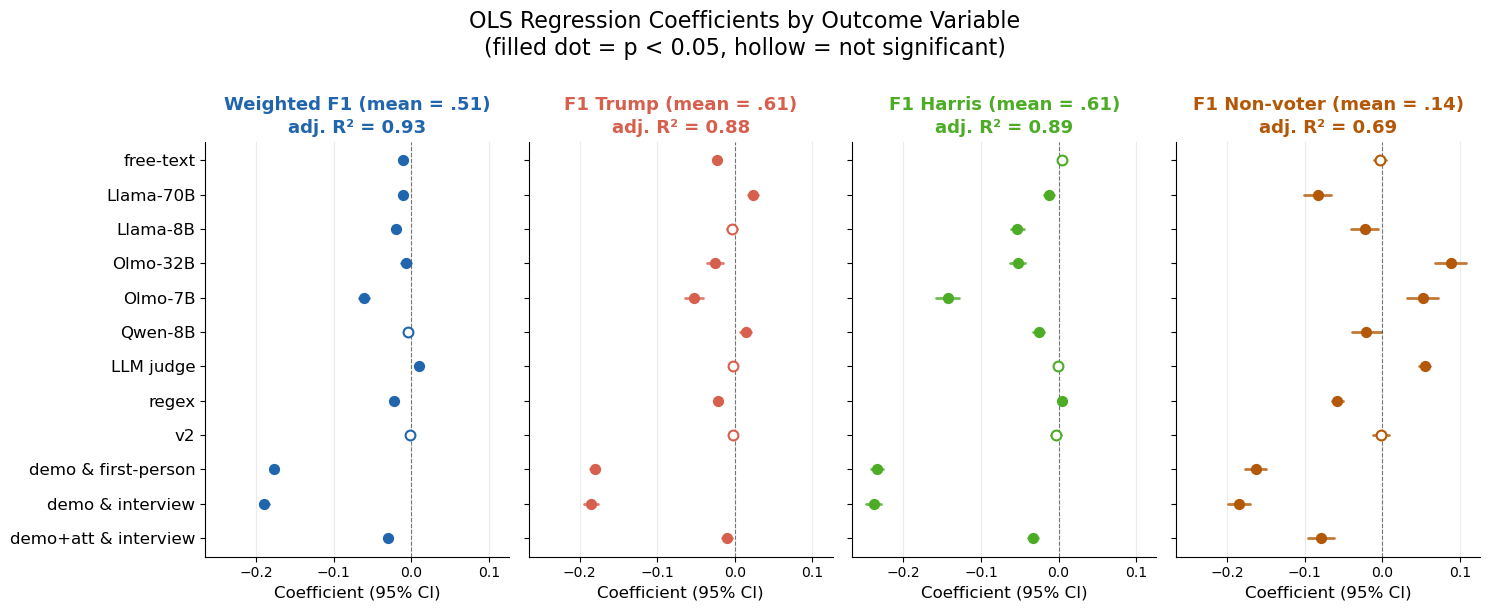

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(15, max(6, n_vars * 0.35 + 1)),
                         sharey=True, sharex = True)

for ax, label, color, reg in zip(axes, model_labels, colors, regs):
    subset = coef_df[coef_df['model'] == label].set_index('label')
    for var in var_order:
        if var not in subset.index:
            continue
        row = subset.loc[var]
        y = y_pos[var]
        sig = row['pvalue'] < 0.05
        # CI stem
        ax.plot([row['ci_low'], row['ci_high']], [y, y],
                color=color, linewidth=2, alpha=0.8, solid_capstyle='round')
        # Dot: filled = significant, hollow = not
        if sig:
            ax.scatter(row['coef'], y, color=color, s=50, zorder=5)
        else:
            ax.scatter(row['coef'], y, facecolors='white', edgecolors=color,
                       linewidths=1.5, s=50, zorder=5)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # ---- Include adjusted R2 in subplot title ----
    adj_r2 = reg.rsquared_adj
    ax.set_title(f'{label}\nadj. R\u00b2 = {adj_r2:.2f}', color=color,
                 fontsize=13, fontweight='bold', linespacing=1.4)

    ax.set_xlabel('Coefficient (95% CI)', fontsize=12)
    ax.grid(axis='x', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_yticks(list(y_pos.values()))
axes[0].set_yticklabels(list(y_pos.keys()), fontsize=12)

fig.suptitle('OLS Regression Coefficients by Outcome Variable\n'
             '(filled dot = p < 0.05, hollow = not significant)',
             fontsize=16, y=1.01)

plt.tight_layout()
plt.savefig('results/regression_lollipop.pdf', dpi=150, bbox_inches='tight')
plt.show()

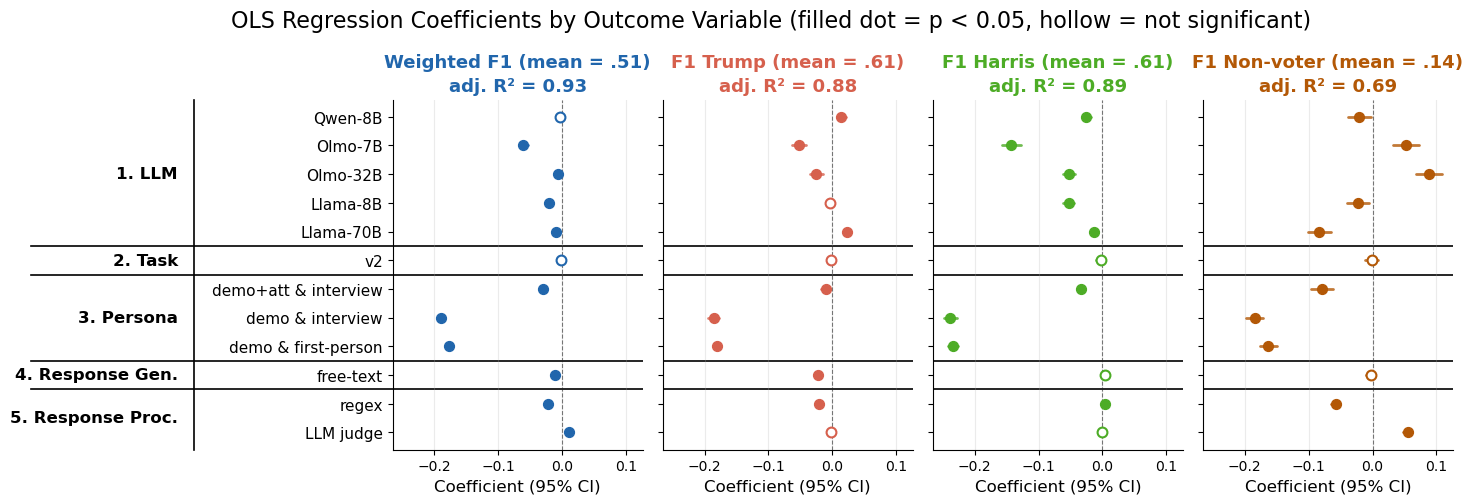

In [37]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.lines
import numpy as np

# ---- Heatmap-style grouped y-axis (LLMs on top) ----
Y_GROUPS = [
    ('1. LLM',            ['Qwen-8B', 'Olmo-7B', 'Olmo-32B', 'Llama-8B', 'Llama-70B']),
    ('2. Task',           ['v2']),
    ('3. Persona',        ['demo+att & interview', 'demo & interview', 'demo & first-person']),
    ('4. Response Gen.',  ['free-text']),
    ('5. Response Proc.', ['regex', 'LLM judge']),

]

ordered_items = [it for _, its in Y_GROUPS for it in its]
n_vars = len(ordered_items)
y_pos = {it: n_vars - 1 - i for i, it in enumerate(ordered_items)}

fig, axes = plt.subplots(1, 4, figsize=(15.5, max(4.9, n_vars * 0.35 + 0.7)),
                         sharey=True, sharex=True)

for ax, label, color, reg in zip(axes, model_labels, colors, regs):
    subset = coef_df[coef_df['model'] == label].set_index('label')
    for var in ordered_items:
        if var not in subset.index:
            continue
        row = subset.loc[var]
        y = y_pos[var]
        sig = row['pvalue'] < 0.05
        ax.plot([row['ci_low'], row['ci_high']], [y, y],
                color=color, linewidth=2, alpha=0.8, solid_capstyle='round')
        if sig:
            ax.scatter(row['coef'], y, color=color, s=50, zorder=5)
        else:
            ax.scatter(row['coef'], y, facecolors='white', edgecolors=color,
                       linewidths=1.5, s=50, zorder=5)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f'{label}\nadj. R\u00b2 = {reg.rsquared_adj:.2f}', color=color,
                 fontsize=13, fontweight='bold', linespacing=1.4)
    ax.set_xlabel('Coefficient (95% CI)', fontsize=12)
    ax.grid(axis='x', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_yticks([y_pos[it] for it in ordered_items])
axes[0].set_yticklabels(ordered_items, fontsize=11)
axes[0].set_ylim(-0.6, n_vars - 0.4)

boundaries, cum = [], 0
for _, its in Y_GROUPS[:-1]:
    cum += len(its)
    boundaries.append((n_vars - 1 - cum) + 0.5)

# reserve a (modest) left gutter for the horizontal group labels
fig.tight_layout(rect=[0.18, 0, 1, 0.96])
fig.canvas.draw()                       # realize tick-label positions

pos = axes[0].get_position()
inv = fig.transFigure.inverted()
rend = fig.canvas.get_renderer()

# left edge of the inner tick labels (figure coords)
inner_left = min(t.get_window_extent(rend).transformed(inv).x0
                 for t in axes[0].get_yticklabels())

divider_x   = inner_left - 0.012        # divider just left of the inner labels
label_right = divider_x - 0.010         # group labels end just left of the divider
sep_left    = divider_x - 0.105         # separators start left of the group labels

trans = mtransforms.blended_transform_factory(fig.transFigure, axes[0].transData)

# (2) horizontal group labels, RIGHT-aligned right next to the inner labels
for header, its in Y_GROUPS:
    yc = np.mean([y_pos[it] for it in its])
    axes[0].text(label_right, yc, header, transform=trans, rotation=0,
                 ha='right', va='center', fontsize=12, fontweight='bold',
                 clip_on=False)

# (3) horizontal separators extended across the gutter (through the group labels)
for b in boundaries:
    fig.add_artist(matplotlib.lines.Line2D([sep_left, pos.x0], [b, b],
                   transform=trans, color='black', linewidth=1.2))  # gutter segment
    for ax in axes:
        ax.axhline(b, color='black', linewidth=1.2, zorder=1)       # panel segments

# vertical divider between group labels and inner labels (height = plot height)
fig.add_artist(matplotlib.lines.Line2D([divider_x, divider_x], [pos.y0, pos.y1],
               transform=fig.transFigure, color='black', linewidth=1.2))

fig.suptitle('OLS Regression Coefficients by Outcome Variable (filled dot = p < 0.05, hollow = not significant)',
             fontsize=16, y=1.02, x = 0.55)

plt.savefig('results/regression_lollipop.pdf', dpi=150, bbox_inches='tight')
plt.show()